<div>
<img src=https://www.institutedata.com/wp-content/uploads/2019/10/iod_h_tp_primary_c.svg width="300">
</div>

# Lab 4.1.1 Linear Regression

## Prediction of House Price Using Linear Regression

### Data

The Sacramento real estate transactions file is a list of 985 real estate transactions in the Sacramento area reported over a five-day period, as reported by the Sacramento Bee.

In [1]:
import pandas as pd
import numpy as np
import pandas as pd

%matplotlib inline

### 1. Explore Data

Perform EDA on this dataset. Use what you have learned so far. Be creative. List all your findings.

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Sacramento_transactions.csv to Sacramento_transactions.csv


In [4]:
# Read CSV
house_csv = "Sacramento_transactions.csv"
df=pd.read_csv(house_csv)

### 2. Predict Price

We are going to predict `price` from available information.

#### 2.1 What is the Target Variable? Why?

In [9]:
# ANSWER
# Price, because we are trying to predict price, which makes it the target

Index(['street', 'city', 'zip', 'state', 'beds', 'baths', 'sq__ft', 'type',
       'sale_date', 'price', 'latitude', 'longitude'],
      dtype='object')

#### 2.2 List all possible variables which might be Predictor variable.

In [ ]:
# ANSWER
# all column names (Variables) besides price, so street, city, zip, state, beds, baths, sq__ft, type, sale_date, latitude, longitude

#### 2.3 Find correlation between variables

Find correlation between variables. Which is the best predictor? Why? State your reason.

In [10]:
# ANSWER
import pandas as pd

# Calculate correlation matrix
correlation_matrix = df.corr(numeric_only=True)
print(correlation_matrix['price'].sort_values(ascending=False))

# The best predictor would be the one with the highest absolute correlation (besides price). So therefore, 'baths' is the best predictor

price        1.000000
baths        0.416208
beds         0.342024
sq__ft       0.333897
longitude    0.284485
latitude    -0.039573
zip         -0.093353
Name: price, dtype: float64


#### 2.4 What is the simplest way to predict price

So we have information for 985 houses. What is the easiest way to predict the price of a house using the price values alone? (Hint: it is a simple calculation)



In [11]:
# ANSWER
# Using the price values alone, you can find the mean

# Calculate the mean price
mean_price = df['price'].mean()
print(mean_price)

234144.26395939087


#### 2.5 Find Residuals

Find difference between actual value and predicted value. Use absolute value.

In [12]:
# ANSWER

# Predict every house's price using the mean
df['predicted_price'] = mean_price

# Calculate residuals (absolute difference between actual and predicted)
df['residual'] = abs(df['price'] - df['predicted_price'])

# VIew head
print(df[['price', 'predicted_price', 'residual']].head())


   price  predicted_price       residual
0  59222    234144.263959  174922.263959
1  68212    234144.263959  165932.263959
2  68880    234144.263959  165264.263959
3  69307    234144.263959  164837.263959
4  81900    234144.263959  152244.263959


#### 2.6  Predict Using Linear Regression

[Simple Linear Regression](https://en.wikipedia.org/wiki/Simple_linear_regression#Fitting_the_regression_line)

### $$\hat{y} = \beta_0 + \beta_1 x$$

> ### $$ \beta_1 = \frac{\sum_{i=1}^n (y_i - \bar{y} ) (x_i - \bar{x} )}{\sum_{i=1}^n (x_i - \bar{x})^2} $$

and

> ### $$ \beta_0 = \bar{y} - \beta_1\bar{x} $$

Given variables:
- $\bar{y}$ : the sample mean of observed values $Y$
- $\bar{x}$ : the sample mean of observed values $X$

##### 2.7 Define X, Y

- X = Predictor Variable
- Y = Target Variable

In [16]:
# ANSWER
X = df['sq__ft']
Y = df['price']


##### 2.7.A Calculate beta_1

 ### $$ \beta_1 = \frac{\sum_{i=1}^n (y_i - \bar{y} ) (x_i - \bar{x} )}{\sum_{i=1}^n (x_i - \bar{x})^2} $$

In [17]:
# ANSWER
# Calculate means
x_mean = X.mean()
y_mean = Y.mean()

# Compute numerator and denominator
numerator = ((X - x_mean) * (Y - y_mean)).sum()
denominator = ((X - x_mean) ** 2).sum()

# Calculate beta_1
beta_1 = numerator / denominator

print(f'beta_1 = {beta_1}')


beta_1 = 54.158639688530755


##### 2.7.B Calculate beta_0

### $$ \beta_0 = \bar{y} - \beta_1\bar{x} $$

In [18]:
# ANSWER
beta_0 = y_mean - beta_1 * x_mean
print(f'beta_0 = {beta_0}')


beta_0 = 162930.16140699777


##### 2.7.C Find Yhat (Predicted Value Using Beta 0 and Beta 1)

### $$\hat{y} = \beta_0 + \beta_1 x$$

In [19]:
# ANSWER
df['y_hat'] = beta_0 + beta_1 * df['sq__ft']

print(df[['sq__ft', 'y_hat']].head())


   sq__ft          y_hat
0     836  208206.784187
1    1167  226133.293924
2     796  206040.438599
3     852  209073.322422
4     797  206094.597239


##### 2.7.D Find Residuals

### $$ \text{residual}_i = y_i - \hat{y}_i$$

In [20]:
# ANSWER
# Calculate residuals
df['residual'] = df['price'] - df['y_hat']

print(df[['price', 'y_hat', 'residual']].head())


   price          y_hat       residual
0  59222  208206.784187 -148984.784187
1  68212  226133.293924 -157921.293924
2  68880  206040.438599 -137160.438599
3  69307  209073.322422 -139766.322422
4  81900  206094.597239 -124194.597239


##### 2.7.E Find R-Squared

The coefficient $R^2$ is defined as $$ R^2 = 1 - \frac{SS_{res}}{SS_{tot}} $$, where $$ SS_{res} $$ is the residual sum of squares $$ SS_{res} = \sum_{i=1}^n \left(y_i - \hat{y}_i\right)^2 $$ and $$ SS_{tot} $$ is the total sum of squares $$ SS_{tot} = \sum_{i=1}^n \left(y_i - \bar{y}\right)^2 $$

The best possible score is 1.0 and it can be negative (because the model can be arbitrarily worse).

**Write a function to calculate R- Squared value.**

The total sum of squares:

### $$ SS_{tot} = \sum_{i=1}^n \left(y_i - \bar{y}\right)^2 $$

The residual sum of squares:

### $$ SS_{res} = \sum_{i=1}^n \left(y_i - \hat{y}_i\right)^2 $$

$R^2$:

### $$ R^2 = 1 - \frac{SS_{res}}{SS_{tot}} $$

In [21]:
# ANSWER
def calculate_r_squared(y_actual, y_predicted):
    y_mean = y_actual.mean()
    ss_res = ((y_actual - y_predicted) ** 2).sum()
    ss_tot = ((y_actual - y_mean) ** 2).sum()
    r_squared = 1 - (ss_res / ss_tot)

    return r_squared


##### 2.7.F [BONUS] Draw Plot of Predicted Line

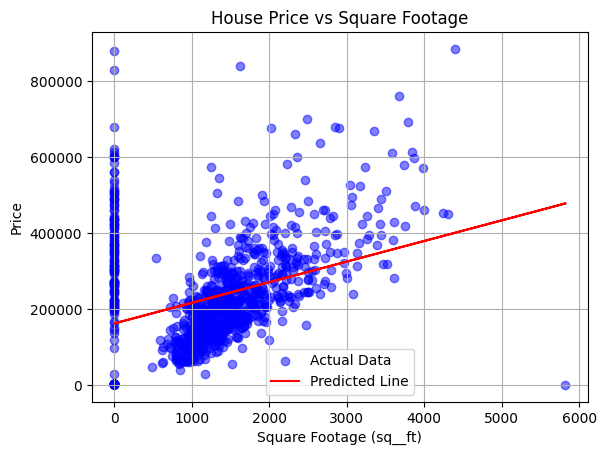

In [23]:
# ANSWER

import matplotlib.pyplot as plt

plt.scatter(df['sq__ft'], df['price'], color='blue', label='Actual Data', alpha=0.5)
plt.plot(df['sq__ft'], df['y_hat'], color='red', label='Predicted Line')

plt.xlabel('Square Footage (sq__ft)')
plt.ylabel('Price')
plt.title('House Price vs Square Footage')
plt.legend()
plt.grid(True)
plt.show()


##### 2.7.G [BONUS] Draw Plot of Predicted Line With Residuals

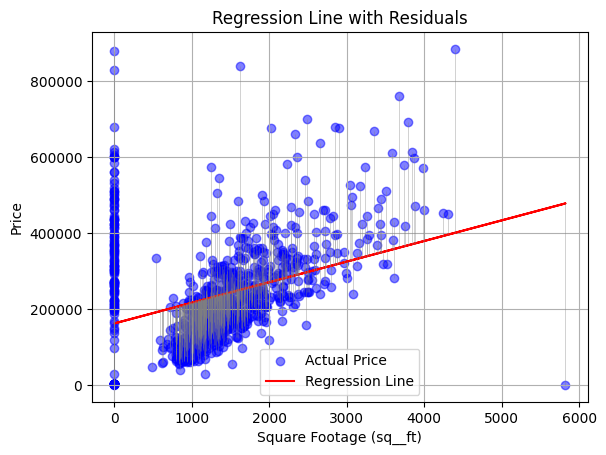

In [25]:
# ANSWER

plt.scatter(df['sq__ft'], df['price'], color='blue', label='Actual Price', alpha=0.5)
plt.plot(df['sq__ft'], df['y_hat'], color='red', label='Regression Line')

# Draw residual lines
for i in range(len(df)):
    plt.vlines(
        x=df['sq__ft'].iloc[i],
        ymin=min(df['price'].iloc[i], df['y_hat'].iloc[i]),
        ymax=max(df['price'].iloc[i], df['y_hat'].iloc[i]),
        color='gray',
        linewidth=0.5,
        alpha=0.5
    )

# Labels, title, legend
plt.xlabel('Square Footage (sq__ft)')
plt.ylabel('Price')
plt.title('Regression Line with Residuals')
plt.legend()
plt.grid(True)
plt.show()

### 3. Predict House Price

Let's assume we have information of following house:

- street:	1140 EDMONTON DR
- city:	SACRAMENTO
- zip:	95833
- state:	CA
- beds:	3
- baths:	2
- sq__ft:	1204
- type:	Residential

**Predict the price of this house.**

In [26]:
# ANSWER
sq_ft = 1204
predicted_price = beta_0 + beta_1 * sq_ft
print(f"Predicted price for 1204 sq__ft house: ${predicted_price:.2f}")


Predicted price for 1204 sq__ft house: $228137.16




---



---



> > > > > > > > > © 2025 Institute of Data


---



---



